<a href="https://colab.research.google.com/github/ShadowKnight711/acm-ml-induction-2026/blob/main/ACM_ML_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

train_df = pd.read_csv('train.csv', sep=';', index_col=0)
test_df = pd.read_csv('test.csv', sep=';', index_col=0)
eval_df = pd.read_csv('evaluation.csv', sep=';', index_col=0)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Eval shape:", eval_df.shape)

print(train_df.columns.tolist())
train_df.head()

Train shape: (24353, 3)
Test shape: (8117, 3)
Eval shape: (8117, 3)
['title', 'text', 'label']


,title,text,label
0,Palestinians switch off Christmas lights in Be...,"RAMALLAH, West Bank (Reuters) - Palestinians s...",1
1,China says Trump call with Taiwan president wo...,BEIJING (Reuters) - U.S. President-elect Donal...,1
2,FAIL! The Trump Organization’s Credit Score W...,While the controversy over Trump s personal ta...,0
3,Zimbabwe military chief's China trip was norma...,BEIJING (Reuters) - A trip to Beijing last wee...,1
4,THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...,There has never been a more UNCOURAGEOUS perso...,0


label
1    13246
0    11107
Name: count, dtype: int64


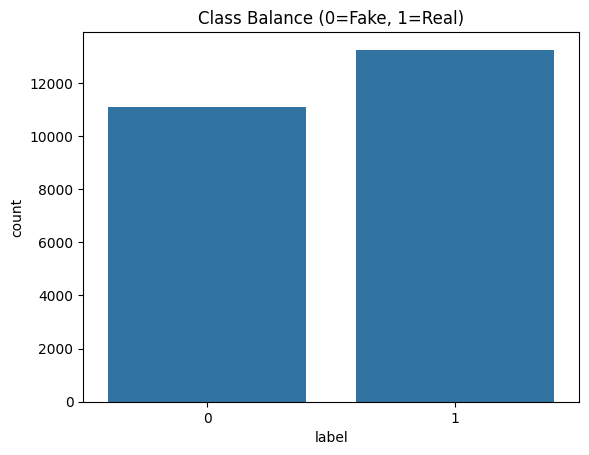

title    0
text     0
label    0
dtype: int64


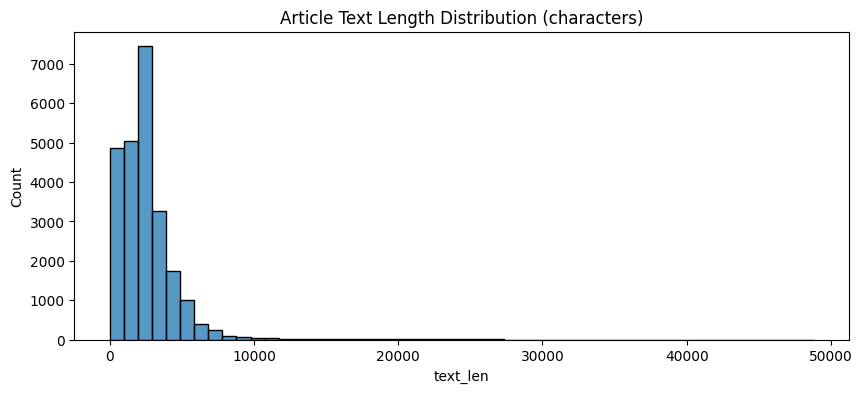

count    24353.000000
mean      2501.703774
std       2114.691683
min          1.000000
25%       1301.000000
50%       2224.000000
75%       3131.000000
max      48835.000000
Name: text_len, dtype: float64


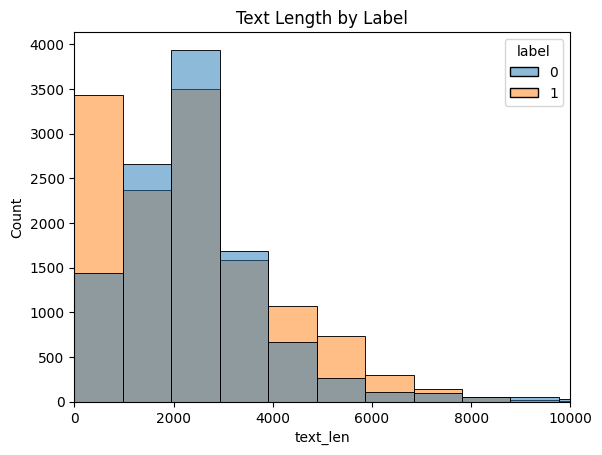

In [ ]:
#Class balance
print(train_df['label'].value_counts())
sns.countplot(x='label', data=train_df)
plt.title('Class Balance (0=Fake, 1=Real)')
plt.show()

#Missing values
print(train_df.isnull().sum())

#Text length distribution
train_df['text_len'] = train_df['text'].astype(str).apply(len)
train_df['title_len'] = train_df['title'].astype(str).apply(len)

plt.figure(figsize=(10,4))
sns.histplot(train_df['text_len'], bins=50)
plt.title('Article Text Length Distribution (characters)')
plt.show()

print(train_df['text_len'].describe())

#Text length by label
sns.histplot(data=train_df, x='text_len', hue='label', bins=50)
plt.title('Text Length by Label')
plt.xlim(0, 10000)  # zoom in, ignore extreme outliers
plt.show()

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)
eval_df['clean_text'] = eval_df['text'].apply(clean_text)

print(train_df[['text', 'clean_text']].head(2))

# Check word counts after cleaning (to help pick max_len)
word_counts = train_df['clean_text'].apply(lambda x: len(x.split()))
print(word_counts.describe())

                                                text  \
0  RAMALLAH, West Bank (Reuters) - Palestinians s...   
1  BEIJING (Reuters) - U.S. President-elect Donal...   

                                          clean_text  
0  ramallah west bank reuters palestinians switch...  
1  beijing reuters u s president elect donald tru...  
count    24353.000000
mean       415.018766
std        350.070994
min          0.000000
25%        215.000000
50%        373.000000
75%        521.000000
max       8017.000000
Name: clean_text, dtype: float64


In [ ]:
# Check for empty rows after cleaning
empty_count = (word_counts == 0).sum()
print("Empty rows after cleaning:", empty_count)
print(train_df[word_counts == 0][['text', 'clean_text', 'label']].head())

Empty rows after cleaning: 33
                                                   text clean_text  label
155   https://fedup.wpengine.com/wp-content/uploads/...                 0
352   https://www.youtube.com/watch?time_continue=2&...                 0
1157  https://www.youtube.com/watch?feature=player_e...                 0
1471        https://www.youtube.com/watch?v=sWbYpIj7CQ8                 0
3638        https://www.youtube.com/watch?v=P-TBfkqk7gU                 0


In [ ]:
# Drop any rows that became empty after cleaning
train_df = train_df[train_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
eval_df = eval_df[eval_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

print("Train shape after dropping empties:", train_df.shape)

# --- Tokenization ---
MAX_VOCAB = 20000
MAX_LEN = 400

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])
eval_sequences = tokenizer.texts_to_sequences(eval_df['clean_text'])

# Pad sequences to the same length
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_eval_pad = pad_sequences(eval_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['label'].values
y_test = test_df['label'].values
y_eval = eval_df['label'].values

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("Vocabulary size actually used:", min(MAX_VOCAB, len(tokenizer.word_index)+1))


print("\\nOriginal text sample:", train_df['clean_text'].iloc[0][:100])
print("Tokenized+padded sample:", X_train_pad[0][:20])

Train shape after dropping empties: (24320, 6)
X_train_pad shape: (24320, 400)
X_test_pad shape: (8107, 400)
Vocabulary size actually used: 20000
\nOriginal text sample: ramallah west bank reuters palestinians switched off christmas lights at jesus traditional birthplac
Tokenized+padded sample: [15333   788   645    62  2219  5859   210  2366  5889    28  3006  2199
 11616     7 12621    10   195   457     7  1034]


In [ ]:
# Drop any rows that became empty after cleaning
train_df = train_df[train_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
eval_df = eval_df[eval_df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

print("Train shape after dropping empties:", train_df.shape)

# --- Tokenization ---
MAX_VOCAB = 20000
MAX_LEN = 400
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])
eval_sequences = tokenizer.texts_to_sequences(eval_df['clean_text'])

# Pad sequences to the same length
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_eval_pad = pad_sequences(eval_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['label'].values
y_test = test_df['label'].values
y_eval = eval_df['label'].values

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("Vocabulary size actually used:", min(MAX_VOCAB, len(tokenizer.word_index)+1))

print("\nOriginal text sample:", train_df['clean_text'].iloc[0][:100])
print("Tokenized+padded sample:", X_train_pad[0][:20])

Train shape after dropping empties: (24320, 6)
X_train_pad shape: (24320, 400)
X_test_pad shape: (8107, 400)
Vocabulary size actually used: 20000

Original text sample: ramallah west bank reuters palestinians switched off christmas lights at jesus traditional birthplac
Tokenized+padded sample: [15333   788   645    62  2219  5859   210  2366  5889    28  3006  2199
 11616     7 12621    10   195   457     7  1034]


In [ ]:
from tensorflow.keras.layers import Input

EMBEDDING_DIM = 128

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 400, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 400, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,702,145 (10.31 MB)

 Trainable params: 2,702,145 (10.31 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Split off a validation set from training data (test.csv stays untouched until final evaluation)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print("Train:", X_tr.shape, "Val:", X_val.shape)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Train: (20672, 400) Val: (3648, 400)
Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9552 - loss: 0.1278 - val_accuracy: 0.9830 - val_loss: 0.0607
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.9894 - loss: 0.0405 - val_accuracy: 0.9827 - val_loss: 0.0615
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - accuracy: 0.9958 - loss: 0.0161 - val_accuracy: 0.9846 - val_loss: 0.0864
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9975 - loss: 0.0082 - val_accuracy: 0.9745 - val_loss: 0.1006


254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step
Test Accuracy: 0.9863
Precision: 0.9960
Recall:    0.9785
F1-score:  0.9872


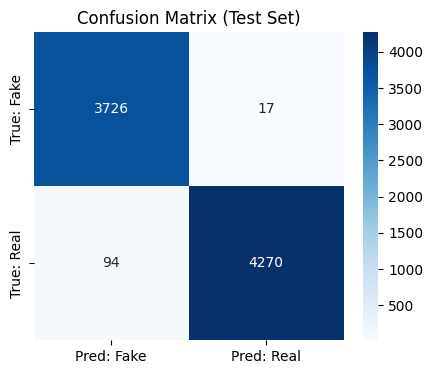

AUC: 0.9960


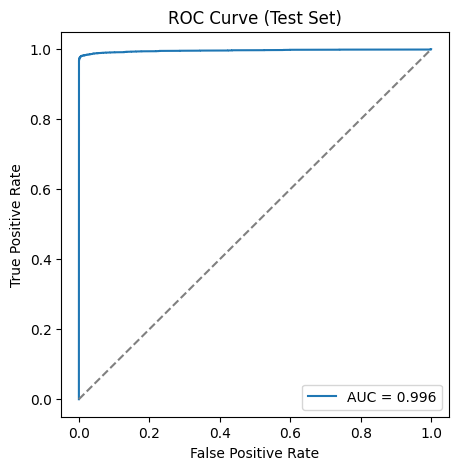

In [ ]:
# Predict probabilities on test set
test_probs = model.predict(X_test_pad).flatten()
test_preds = (test_probs >= 0.5).astype(int)

# Accuracy
test_acc = np.mean(test_preds == y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix (manual, consistent with Task 1's style)
tp = np.sum((y_test == 1) & (test_preds == 1))
tn = np.sum((y_test == 0) & (test_preds == 0))
fp = np.sum((y_test == 0) & (test_preds == 1))
fn = np.sum((y_test == 1) & (test_preds == 0))

precision = tp / (tp + fp) if (tp+fp) > 0 else 0
recall = tp / (tp + fn) if (tp+fn) > 0 else 0
f1 = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Confusion matrix plot
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Fake','Pred: Real'],
            yticklabels=['True: Fake','True: Real'])
plt.title('Confusion Matrix (Test Set)')
plt.show()

# AUC using sklearn (allowed here - it's not a banned tree/ensemble class)
from sklearn.metrics import roc_curve, auc as sklearn_auc

fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = sklearn_auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.show()

In [ ]:
def predict_news(text, model, tokenizer, max_len=MAX_LEN):

    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Real" if prob >= 0.5 else "Fake"
    return label, float(prob)

#  Test on a few custom examples
examples = [
    "Breaking: Government announces new policy on healthcare reform after months of negotiation.",
    "You won't believe what doctors don't want you to know about this one weird trick!",
    "Scientists confirm water boils at 100 degrees Celsius at sea level in new peer-reviewed study."
]

for ex in examples:
    label, prob = predict_news(ex, model, tokenizer)
    print(f"Text: {ex[:80]}...")
    print(f"Prediction: {label} (confidence: {prob:.4f})\n")

# Run inference on the actual evaluation.csv (unseen data)
eval_probs = model.predict(X_eval_pad).flatten()
eval_preds = (eval_probs >= 0.5).astype(int)

eval_df['predicted_label'] = eval_preds
eval_df['confidence'] = eval_probs

print(eval_df[['title', 'predicted_label', 'confidence']].head(10))

# If evaluation.csv has true labels, check accuracy too
if 'label' in eval_df.columns:
    eval_acc = np.mean(eval_preds == eval_df['label'].values)
    print(f"\nEvaluation set accuracy: {eval_acc:.4f}")

Text: Breaking: Government announces new policy on healthcare reform after months of n...
Prediction: Fake (confidence: 0.0270)

Text: You won't believe what doctors don't want you to know about this one weird trick...
Prediction: Fake (confidence: 0.0091)

Text: Scientists confirm water boils at 100 degrees Celsius at sea level in new peer-r...
Prediction: Fake (confidence: 0.0142)

254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
                                               title  predicted_label  \
0  Sanders back in U.S. Senate, blasts 'coloniali...                1   
1  Kremlin: Syria peoples' congress being 'active...                1   
2   Oregon Cop Convicted Of Shattering Biker’s Co...                0   
3   Twitter Erupts With Glee Over #CruzSexScandal...                0   
4  MUST WATCH VIDEO: Obama Tries To Trash Trump B...                0   
5   AL Cops Kill Suicidal Woman After Her Parents...                0   
6  U.S. judge to mull release of Trump video test...        

In [ ]:
long_examples = [
    # Reuters-style real news
    """WASHINGTON (Reuters) - The White House announced on Tuesday a new set of trade
    measures aimed at reducing tariffs on imported steel, following months of negotiation
    with European Union officials. The policy, which takes effect next month, is expected
    to lower costs for domestic manufacturers while easing tensions between the two
    economic blocs, according to a statement released by the Commerce Department.""",

    # Sensationalist fake-style
    """You won't believe what happened next! Local mom discovers ONE simple trick that
    doctors HATE and Big Pharma doesn't want you to know about. Share this before it
    gets DELETED! Thousands are already talking about this shocking secret that could
    change your life forever. Click here to find out more before it's too late!""",

    # Neutral factual statement, non-Reuters style
    """A new study published in a peer-reviewed journal this week found that regular
    exercise is associated with improved cardiovascular health in adults over 50.
    Researchers followed over 2,000 participants across five years and observed
    a measurable reduction in heart disease risk among those who exercised regularly."""
]

for ex in long_examples:
    label, prob = predict_news(ex, model, tokenizer)
    print(f"Text: {ex[:100].strip()}...")
    print(f"Prediction: {label} (confidence: {prob:.4f})\n")

Text: WASHINGTON (Reuters) - The White House announced on Tuesday a new set of trade 
    measures aimed a...
Prediction: Real (confidence: 0.9998)

Text: You won't believe what happened next! Local mom discovers ONE simple trick that 
    doctors HATE an...
Prediction: Fake (confidence: 0.0118)

Text: A new study published in a peer-reviewed journal this week found that regular 
    exercise is assoc...
Prediction: Fake (confidence: 0.0223)

